In [1]:
%matplotlib notebook
from fits_mask_tools import FitsViewer, BackgroundInteractive, MaskPainter
import matplotlib.pyplot as plt
import numpy as np
import h5py

## Images

These are the images we will work with.

They start as a clean mosaic of galaxy cutouts placed on a large blank canvas. A set of point sources with a simple, fixed Gaussian PSF is added so that the frames contain some compact objects. After that, a smooth polynomial sky is applied, followed by Poisson noise from the sky and a small Gaussian term to mimic additional scattered light. This setup lets us control the large-scale sky structure and noise statistics, which makes it easier to study how the background model behaves as you vary the spatial scale.

There are some limitations. The sky is idealised, the PSF does not vary, the star population is simplified, and real instrumental artefacts are not included. The images are therefore good for controlled experiments, but they are a bit more forgiving than real survey data.

In [2]:
from galaxylib import GalaxyLibrary

FLUXMAG0 = 63095734448.0194
IMAGE_PSF = 5.0
library_path = './library'

lib = GalaxyLibrary(library_path)
library_files = lib.load_and_plot()

n_x = 5000
n_y = 5000

canvas = lib.create_canvas((5000, 5000), n_objects=150, seed=21, z_min=0.1)

canvas = lib.inject_specific(canvas, [
                                    ('obj_00019_z0.05_658.h5', 500, 1500),
                                    ('obj_00135_z0.05_904.h5', 1500, 1500),
                                    ('obj_00038_z0.05_658.h5', 2500, 4000),
                                    ('obj_00073_z0.05_791.h5', 2000, 3000),
                                    ('obj_00009_z0.05_904.h5', 2500, 2500),
                                    ('obj_00076_z0.05_658.h5', 3000, 4000),
                                    ('obj_00028_z0.05_791.h5', 1000, 4500),
                                    ('obj_00025_z0.05_658.h5', 2000, 2000),
                                    ('obj_00138_z0.05_904.h5', 500, 2500),
                                    ('obj_00003_z0.05_791.h5', 3500, 3000),
                                    ('obj_00001_z0.05_658.h5', 3000, 3500),
                                    ('obj_00003_z0.05_904.h5', 2000, 3250),
                                ])


canvas = lib.inject_specific(canvas, [('obj_00001_z0.05_904.h5', n_x//2-1200, n_y//2-1200)],
scale=2.0, flux_scale=10.0)
canvas = lib.inject_specific(canvas, [('obj_00019_z0.05_904.h5', n_x//2, n_y//2)],
scale=4.0, flux_scale=25.0)


canvas_adu = canvas * FLUXMAG0

img_sky, bg_model, noise = lib.add_sky( canvas_adu,
                                 mean_sky_adus=np.max(canvas_adu) / 10.,
                                 poly_coeffs={
                                     (1, 0): 0.5,
                                     (0, 1): 0.5,
                                     (2, 0): 0.5,
                                     (0, 2): -0.5 },
                                 additional_noise_sigma=0.5,
                                 n_stars=500,
                                 star_flux_range=(100., 3000.),
                                 psf_sigma=2.5,
                                 gain=3*100,
                                 seed=1 )

<IPython.core.display.Javascript object>


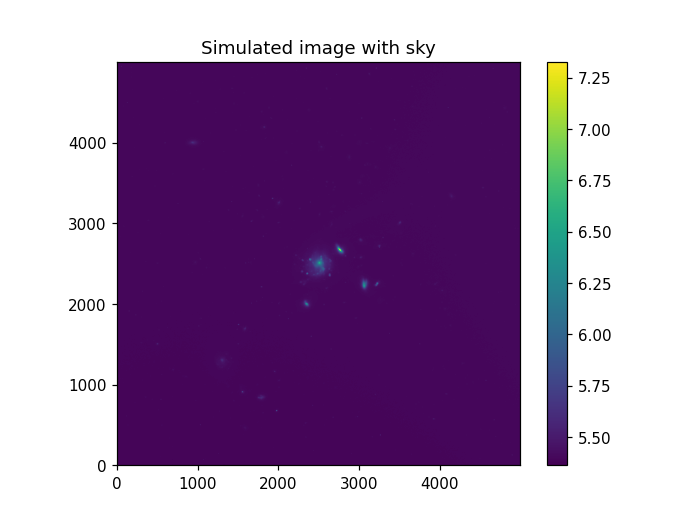

Text(0.5, 1.0, 'Simulated image with sky')

In [3]:
plt.figure()
h = plt.imshow(np.arcsinh(img_sky), origin='lower')
plt.colorbar(h)
plt.title('Simulated image with sky')

## Background estimation

### Sources of Background

In astronomical imaging, the measured signal contains not only light from astrophysical sources, but also a variety of unwanted contributions collectively referred to as the background. Understanding these components is important because each behaves differently across the detector and may require different strategies for removal.

Some common sources of background include:

- **Sky glow.** Emission from the Earth's atmosphere, including airglow lines and scattered moonlight or twilight, produces a smooth but sometimes spatially varying background that changes over time.  
- **Zodiacal light.** Sunlight scattered by interplanetary dust introduces a low-level, often nearly uniform illumination across the field.  
- **Galactic cirrus.** Diffuse, filamentary dust clouds in the Milky Way that scatter starlight and emit at infrared wavelengths. Cirrus structures are faint and spatially variable, often creating low-surface-brightness features that can be mistaken for extragalactic emission. Because their morphology is complex and covers a wide range of spatial scales, cirrus is difficult to model or remove using standard background estimation. Auxiliary infrared observations are often used to identify and characterise cirrus, helping to distinguish it from genuine astrophysical sources in the optical or near-infrared.
- **Scattered light and reflections.** Internal reflections within the telescope or camera optics, such as ghosts or halos around bright stars, produce structured background patterns that may be localized or extend across the field.  
- **Instrumental artefacts and CCD-to-CCD variations.** In mosaic cameras or multi-amplifier detectors, each CCD or amplifier can have slightly different sensitivity, bias level, or flat-field response. This produces small step-like differences or gradients across the field. If uncorrected, these differences appear as residual background structure and can interfere with the detection of faint sources.

Each of these sources has characteristic spatial and temporal behaviour. Some vary slowly across the frame (e.g., zodiacal light), while others are more localized (e.g., scattered-light ghosts) and some are diffuse but structured on intermediate scales (e.g., Galactic cirrus).


### Modelling the Background

Background estimation is sensitive to both the spatial scale of genuine sky variations and the characteristic sizes of astrophysical sources. A practical approach is to divide the image into tiles and estimate a representative value within each. The choice of tile size matters, because it sets the scale over which the background is allowed to vary.

A background that is measured over very small regions tends to track local fluctuations too closely. Noise peaks, faint wings of galaxies, or scattered light can all be misinterpreted as real structure in the background. The resulting model becomes noisy and can imprint artificial patterns on any subsequent measurements.

At the other extreme, very large regions enforce a background that varies too slowly. Genuine gradients, for example from moonlight, twilight residuals, internal reflections, or flat-field imperfections, are averaged out. The fitted surface then underestimates the large-scale structure and leaves systematic residuals across the frame.

Underestimating the background leads to overly bright flux measurements, while overestimating it suppresses faint sources. Spatially varying errors can also bias shape measurements or affect detection thresholds differently across the field.

The choince of tile size therefore needs to avoid both extremes. It should be large enough to smooth over pixel noise and small-scale source structure, but small enough to capture slow gradients across the detector. Once a suitable range has been explored, the resulting model can be inspected by subtracting it from the contaminated image and checking the residuals.

### Other Factors


We will not vary these parameters in the exercise, several additional parameters influence how well the background estimate represents the true sky. They are secondary to the choice of spatial scale but still worth understanding.

- **Filter size.**  
  Once the background has been measured in separate tiles, a smoothing step links those tiles into a continuous surface. If the filter is too small, the background retains the imprint of the grid and develops visible discontinuities. If the filter is too large, the smoothing begins to suppress genuine low-frequency structure. In practice, the filter needs only to be large enough to remove the block pattern without forcing the background to become artificially flat.

- **Sigma clipping.**  
  The estimation procedure attempts to restrict itself to sky pixels by removing outliers. Sigma clipping performs this rejection automatically, but the threshold determines how aggressively the data are trimmed. Weak clipping allows bright pixels to leak into the estimate and raises the inferred background. Strong clipping discards too much of the distribution and can erase real variations in very faint regions. A moderate setting is usually adequate and avoids both extremes.

Although these parameters are not adjusted here, they often explain residual structure in background models. Checkerboard patterns usually point to insufficient filtering, while elevated regions around bright sources indicate insufficient clipping. Understanding these behaviours makes it easier to diagnose problems when analysing real observations.

### Limitations

Background modelling is inevitably a compromise between capturing genuine large-scale structure and avoiding contamination from astrophysical sources. Several constraints follow from this.

- **No single parameter set works for all images.**  
  The optimal tile size depends on the characteristic scales present in the field. Images dominated by compact objects can tolerate smaller tiles, whereas data containing extended galaxies or diffuse emission require larger ones to avoid suppressing real structure. A configuration that performs well for one field may fail for another.

- **Bright or extended sources complicate the estimate.**  
  Very bright stars, large galaxies, or scattered-light halos inflate the local pixel distribution and bias the background upwards. In these cases, it might be necessary to mask these regions or model them explicitly by fitting and subtracting a model PSF or subtracting a smooth galaxy profile before attempting any background estimation.

- **Low-surface-brightness features are vulnerable to over-subtraction.**  
  Diffuse structures that vary slowly across the image sit close to the noise level and can easily be modelled as background. If the chosen scale is too small, these features are partially removed; if too large, they remain but any structure that changes more rapidly than the background model (such as faint galaxy outskirts, tidal features, or diffuse intra-cluster light) can be washed out by variations in the true sky background that are not captured by the model background.

These limitations underline that background estimation requires awareness of the characteristic scales in the data and an understanding of which structures should be preserved and which should be removed.

## Exercise: finding the optimum box size

### What the panels tell you

- **Background map (left).** Should be smooth on the scale set by the box size. If the map shows sharp edges, patchiness, or shapes that mimic bright sources, the algorithm is being influenced by objects rather than by the sky.
- **Residual image (right).** Should ideally contain only sources and noise. Any broad gradients or dark haloes around objects indicate the background model is not well matched to the image.

### Why box size matters

The box (tile) size defines the spatial scale on which the background is assumed to vary.

- **Box size too small.**  
  Small boxes give medians that are easily biased by even a few bright pixels. The estimator starts to see parts of astronomical objects as background because the box does not contain enough uncontaminated pixels. This leads to over-subtraction: galaxies may look hollowed out, and faint extended emission is suppressed. 

- **Box size too large.**  
  Large boxes act like a strong low-pass filter, so only very broad features appear in the background model. The estimator averages over too much of the image and fails to follow real sky gradients or scattered-light features. These structures remain visible in the residual as large, smooth patterns.

### Exercise

Background estimation is sensitive to the presence of bright or extended sources, and to the choice of spatial scale and other parameters. Visual inspection of the residuals is the most reliable way to assess whether the model is appropriate.

1. **Explore the effect of box size.** Run the cell below. Start with a range of box sizes and compute the background for each. Examine how small boxes may overfit local fluctuations around sources, while large boxes may fail to capture gradients in the sky. Note how the residuals change around extended sources.

2. **Assess smoothing and clipping.** Consider how the filter size and sigma clipping affect the smoothness and accuracy of the background. (In this exercise, you will not adjust these parameters, but observe their influence on the residual.)

3. **Identify problematic regions.** Click on the residual to zoom into bright stars, extended galaxies, and blank sky. Look for over- or under-subtraction. 

4. **Examine the relevant scales.** Consider the characteristic sizes of sources or diffuse structures you wish to retain in the image. Select initial box sizes that are large enough not to suppress these features, and small enough to capture global sky variations. Generate background models using a range of box sizes. Focus on whether the scales of interest are preserved.

5. **Inspect the residuals.** Once you have a background that you are happy preserves the desired scales, examine the residual histogram by running ```bg_viewer.plot_residual_hist()``` in the cell below to verify that empty sky is noise-dominated. Skewed distributions, long tails, or large-scale gradients indicate over- or under-subtraction. This function overlays a Gaussian derived from the expected noise with the distribution of values from the residual image. A noise-dominated residual should have a roughly Gaussian distribution centred on zero. Skewness or long tails indicate leftover sources, gradients, or artefacts. The width of the distribution gives the noise level. 

6. **Iterate as needed.** Adjust box size and recompute until the residuals in empty sky are noise-dominated, and genuine astronomical sources retain their expected morphology.

The goal is first to develop an intuitive understanding of how the background estimation behaves under different choices, and then to converge on a scale that removes only the unwanted sky while preserving real structures.

<IPython.core.display.Javascript object>


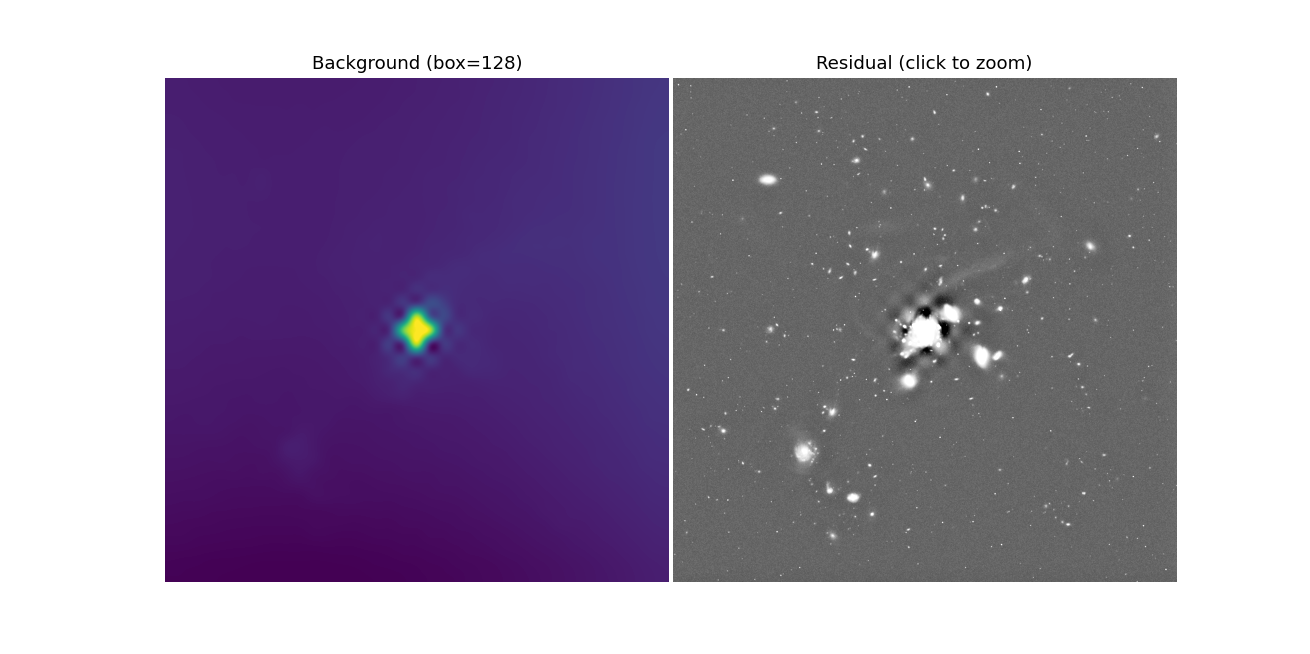

interactive(children=(IntSlider(value=128, continuous_update=False, description='box size', max=1024, min=32, …

In [4]:
bg_viewer = BackgroundInteractive(img_sky, zoom_size=500)
bg_viewer.interact()

<IPython.core.display.Javascript object>


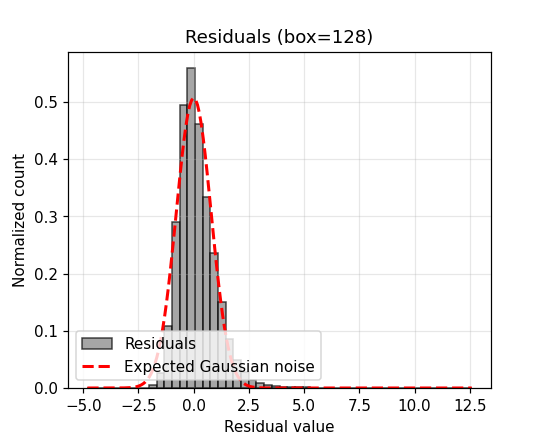

In [5]:
bg_viewer.plot_residual_hist() # rerun this cell to update the histogram for the current box size above

## Image scaling

### Image display parameters

Scaling and stretch determine how pixel values are mapped to display brightness. For low-surface-brightness work this is critical: the wrong choice either buries faint structure in the black point or exaggerates noise and residual sky structure. The interactive controls below let you trade dynamic range for local contrast and choose a nonlinear mapping that reveals faint wings without saturating bright cores.

There are a number of ways that we can rescale an image to emphasise the features we are interested in:

- **Stretch (linear / log / sqrt / asinh).** Nonlinear stretches (asinh, sqrt) compress bright cores while raising faint signal above the background floor. Asinh is usually the safest first choice for faint extended features; log often over-amplifies noise.

- **Contrast.** Controls the effective slope of the transfer function. Lower contrast spreads values and helps see faint gradients; higher contrast emphasises edges and compact structure.

- **White fraction**. Sets where the display’s white point lies between vmin and vmax. Moving it down makes the brightest pixels less dominant and can bring out faint structures.

- **Scaling (%).** Lowering the percentile range (e.g. 95–99) includes more high and low pixels and can expose faint diffuse light, but also risks showing outliers and detector artefacts.

Faint extended emission exists very close to the noise floor. Nonlinear stretches that gently compress high values (asinh, sqrt) increase the visibility of low counts without clipping bright regions. But any increase in visibility is coupled with amplification of noise and low-level residuals from imperfect background subtraction.

### Exercise: choosing display parameters to reveal low-surface-brightness features

Work after you have picked a background box size with ```bg_viewer``` in the previous exercise. The new plot inherits your chosen box size.

1. **Select a stretch.**  
   Find a stretch that best reveals faint features. Asinh or sqrt usually works well. Note if faint structures appear continuous or grainy (noise).

2. **Adjust contrast.**  
   Reduce contrast in steps. Inspect faint haloes or tidal features at each step: coherent structures indicate successful enhancement; speckled or patchy patterns indicate amplified noise.

3. **Lower the white point.**  
   Decreasing the white fraction slightly de-emphasises bright cores and makes faint outskirts more visible. Adjust incrementally and observe changes.

4. **Inspect with the zoom tool.**  
   Use the rectangle tool to zoom into regions of interest and the home icon to reset. The inset zoom can help evaluate the morphology: real emission is spatially coherent, while noise is patchy and uncorrelated.

5. **Iterate for optimal settings.**  
   Combine stretch, contrast, and white fraction to highlight faint structures without exaggerating noise or residual gradients.  

6. **Record final values.**  
   Once satisfied, note the final display parameters (stretch, contrast, white fraction, scaling) along with the box size used for the background model.
   
Careful adjustment of image scaling and stretch is important for visualising faint, extended features without misleading amplification of noise or residual background. By iteratively exploring stretch type, contrast, white point, and scaling, you can reveal low-surface-brightness structures in a controlled and consistent way. Record the settings that best preserve coherent faint emission.

<IPython.core.display.Javascript object>


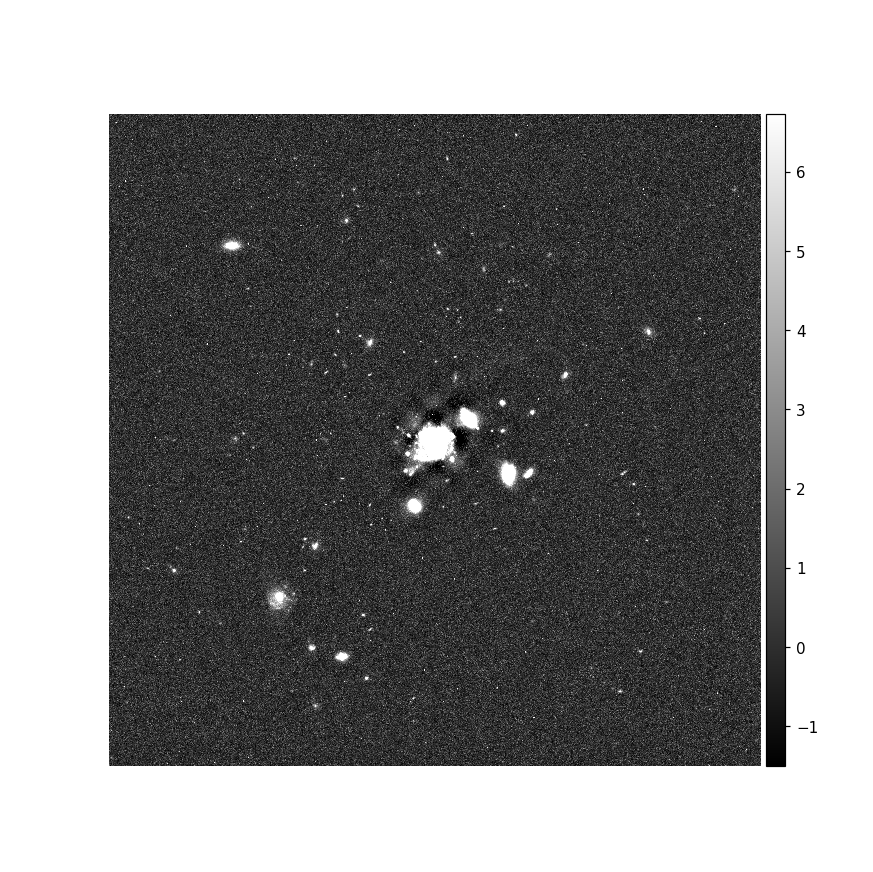

interactive(children=(Dropdown(description='stretch', options=('linear', 'log', 'sqrt', 'asinh'), value='linea…

Button(button_style='success', description='take snapshot', style=ButtonStyle())

In [6]:
fv = FitsViewer(bg_viewer.resid)

### The MaskPainter takes the current state of the FitsViewer and allows us to paint multiple masks over the image.

<IPython.core.display.Javascript object>


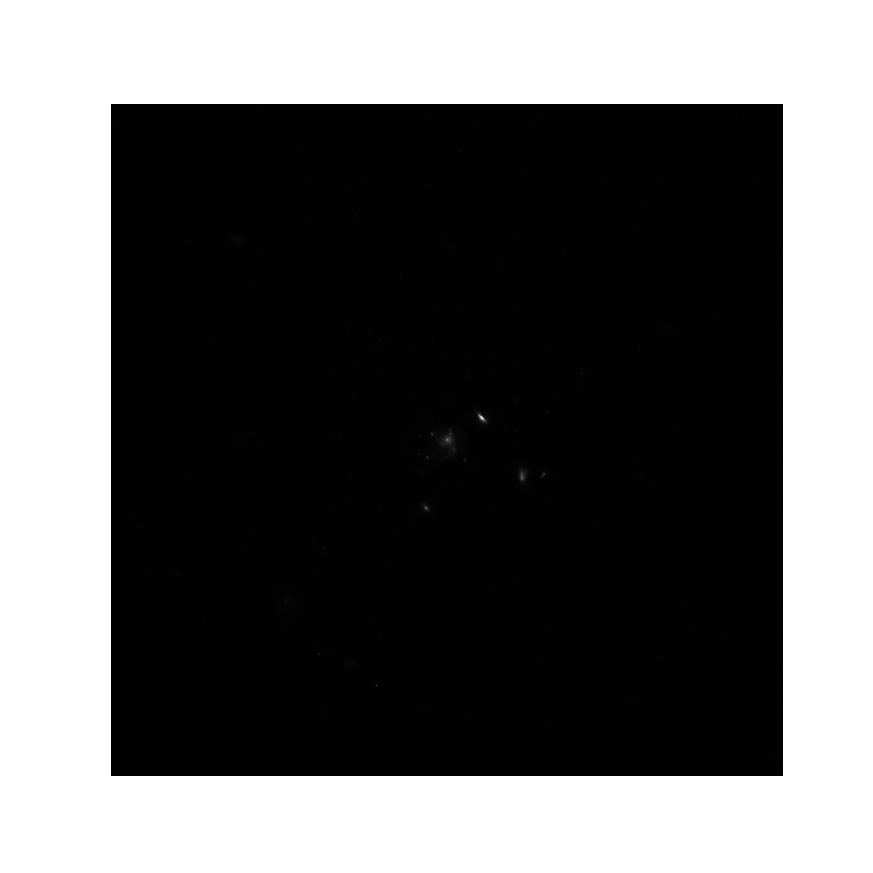

MaskPainter ready — click to create a zoom crop, paint, then commit.


In [7]:
painter = MaskPainter(fv)

### Finally, we can pass the mask file back to FitsViewer to view only the masked pixels.

In [8]:
fv_masked = FitsViewer("test_image.fits", hdu_index=0, crop=crop, mask_file='./masks/mask_000.fits')

NameError: name 'crop' is not defined

### We can also retrieve the maked data directly and do whatever we want with it.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

masked_array = fv_masked.masked_data_cropped

fig, ax = plt.subplots(figsize=(6,6))
ax.set_axis_off()

im = ax.imshow(np.log10(masked_array), origin='lower', cmap='jet', interpolation='nearest')
plt.show()